# Partenza da uno standard di 5 giorni di lag
1. import librerie
2. scarico e pulisco i dati
3. funzione per i 5 giorni di lag `shift`

In [106]:
import pandas as pd
import yfinance as yf
from sklearn.discriminant_analysis import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [107]:
def get_clean_data(period="2y"):
    assets = ["HG=F", "DX-Y.NYB", "CL=F"]
    raw_data = yf.download(assets, period=period)
    close_price = raw_data['Close'] # type: ignore
    close_price.columns = ["Copper", "USD", "Crude_Oil"] # type: ignore
    df_returns = close_price.pct_change().dropna()
    return df_returns

def prepare_multilag(df: pd.DataFrame, lags=5, target="Copper"):
    X_list = []
    for i in range(1,lags+1):
        # creo un dataframe shiftato di i-posizioni
        df_lagged = df.shift(i)
        # rinomino le colonne per renderle distinguibili
        df_lagged.columns = [f"{col}_lag_{i}" for col in df_lagged.columns]
        # aggiungo il dataframe alla lista
        X_list.append(df_lagged)
    # concateno tutti i dataframe che ho fino ad ora (axis=1 per le colonne)
    X = pd.concat(X_list, axis=1).dropna()
    # il target viene allineato con la data (il target di oggi (t) fa riferimento alla riga di t-1, t-2, t-3 ... t-lags)
    y = df[target].loc[X.index]
    return X, y

# senza argomenti sono 2 anni
df_returns = get_clean_data()

# scalo i risultati in modo che siano coerenti tra loro
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(df_returns)
df_scaled = pd.DataFrame(scaled_returns, columns=df_returns.columns, index=df_returns.index)

X, y = prepare_multilag(df_scaled) # type: ignore

[*********************100%***********************]  3 of 3 completed


### Risultati
Ora ho X, y dove:  
- X = I ritorni in percentuale e scalati dei vari ticker laggati di 5 giorni
- y = Variazione del prezzo del target (in questo caso Copper) del giorno sempre scalato
---
## Divisione 80% train - 20% test

In [108]:
split_index = int(len(df_scaled) * 0.8)

# diviso X in 80 20
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
# diviso y in 80 20
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

## Matrice di correlazione
Il test della vista  
La faccio solo sul train, perchè se esistessa una correlazione forte sul test il modello non la vedrebbe

                 Target_Copper
Copper_lag_1          0.013675
USD_lag_1             0.045136
Crude_Oil_lag_1       0.088337
Copper_lag_2          0.058729
USD_lag_2             0.070272
Crude_Oil_lag_2      -0.046459
Copper_lag_3         -0.031217
USD_lag_3            -0.104647
Crude_Oil_lag_3       0.099204
Copper_lag_4         -0.081302
USD_lag_4            -0.118735
Crude_Oil_lag_4       0.026027
Copper_lag_5         -0.083107
USD_lag_5            -0.051964
Crude_Oil_lag_5       0.064736


<Axes: >

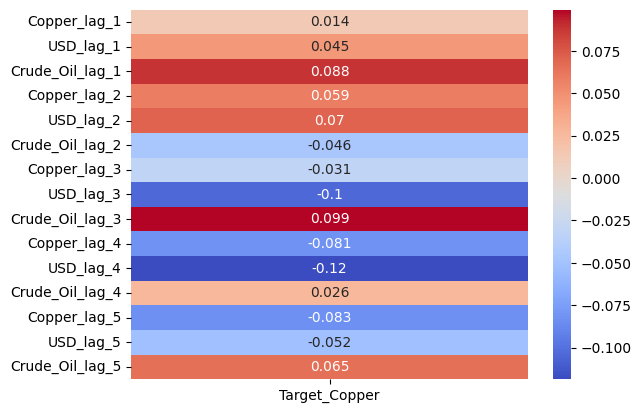

In [109]:
# unisco X e y per vedere le correlazioni
train_analysis = X_train.copy()
train_analysis['Target_Copper'] = y_train

corr_analysis = train_analysis.corr()[['Target_Copper']].drop("Target_Copper")
print(corr_analysis)
sns.heatmap(corr_analysis, annot=True, cmap="coolwarm")

## Risultati
Numeri intorno allo 0.1 sono buoni, in finanza 95% è dettato da forze superiori (tweet, movimenti macro-economici, cambio dei tassi)  
- USD lag 3 e 4, se il dollaro sale, il Copper scende con 3/4 giorni di ritardo, le aziende ci mettono un po' per aggiornarsi
- Crude_oil 1 e 3, se il petrolio sale, il Copper sale a 1 giorno e 3 giorni, probabilmente un "sentiment" della popolazione rispetto alle materie prime

In [110]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- STATS ---")
print(f"Errore medio: {rmse}")
print(f"R2 score: {r2}")

importances = pd.Series(model_rf.feature_importances_, index=X_train.columns)
print("--- COSA HA GUARDATO DAVVERO LA FORESTA? ---")
print(importances.sort_values(ascending=False).head(10))

--- STATS ---
Errore medio: 1.0485334135635047
R2 score: -0.08947981589175558
--- COSA HA GUARDATO DAVVERO LA FORESTA? ---
Copper_lag_1       0.171586
Copper_lag_5       0.157126
Copper_lag_2       0.144297
Crude_Oil_lag_3    0.063928
USD_lag_5          0.056128
Copper_lag_4       0.055511
Copper_lag_3       0.053835
USD_lag_4          0.050921
USD_lag_1          0.043293
USD_lag_2          0.040946
dtype: float64


### Risultati
Il modello si basa sul passato del Copper per indovinare il Copper  
Proviamo ad esluderlo visto che sulla matrice di correlazione vediamo collegamenti con dollaro e petrolio

In [111]:
# Rimuoviamo tutte le colonne che contengono "Copper_lag"
X_train_no_copper = X_train.drop(columns=[col for col in X_train.columns if "Copper_lag" in col])
X_test_no_copper = X_test.drop(columns=[col for col in X_test.columns if "Copper_lag" in col])

# Rilancia il modello
model_rf.fit(X_train_no_copper, y_train)
y_pred_no_copper = model_rf.predict(X_test_no_copper)

print(f"R2 Score (Solo USD e Oil): {r2_score(y_test, y_pred_no_copper):.4f}")
importances = pd.Series(model_rf.feature_importances_, index=X_train_no_copper.columns)
print("--- LA NUOVA GERARCHIA DELLE VARIABILI ---")
print(importances.sort_values(ascending=False).head(10))

R2 Score (Solo USD e Oil): -0.0472
--- LA NUOVA GERARCHIA DELLE VARIABILI ---
USD_lag_1          0.137976
USD_lag_4          0.133141
USD_lag_3          0.125670
Crude_Oil_lag_3    0.116697
Crude_Oil_lag_4    0.094938
USD_lag_5          0.090457
USD_lag_2          0.086251
Crude_Oil_lag_5    0.076496
Crude_Oil_lag_1    0.072252
Crude_Oil_lag_2    0.066122
dtype: float64


### Risultati
- R2 = -0.04, risultato scadente
---
## Media mobile

In [117]:
df_returns["USD_Trend"] = df_returns["USD"].rolling(window=5).mean()
df_returns["Crude_Oil_Trend"] = df_returns["Crude_Oil"].rolling(window=5).mean()
df_returns_trend = df_returns.dropna()

X_trend, y_trend = prepare_multilag(df_returns_trend, lags=5)

Rimuovo le colonne del copper che fanno solo rumore

In [131]:
X_trend = X_trend.drop(columns=[col for col in X_trend.columns if "Copper_lag" in col])

# 1. Split Temporale (80/20)
split = int(len(X_trend) * 0.8)
X_train_trend, X_test_trend = X_trend.iloc[:split], X_trend.iloc[split:]
y_train_trend, y_test_trend = y_trend.iloc[:split], y_trend.iloc[split:]

model_trend = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# 3. Training e Predizione
model_trend.fit(X_train_trend, y_train_trend)
y_pred_t = model_trend.predict(X_test_trend)

# 4. Metriche
from sklearn.metrics import r2_score
print(f"R2 Score con Trend: {r2_score(y_test_trend, y_pred_t):.4f}")

R2 Score con Trend: -0.0218
